# 01. PyTorch Workflow Fundamentals

The essence of machine learning and deep learning is to take some data from the past, build an algorithm (like a neural network) to discover patterns in it and use the discovered patterns to predict the future.



## What we're going to cover

In this module we're going to cover a standard PyTorch workflow (it can be chopped and changed as necessary but it covers the main outline of steps).

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png" width=900 alt="a pytorch workflow flowchat"/>

we're going to cover:

| **Topic** | **Contents** |
| ----- | ----- |
| **1. Getting data ready** | Data can be almost anything but to get started we're going to create a simple straight line |
| **2. Building a model** | Here we'll create a model to learn patterns in the data, we'll also choose a **loss function**, **optimizer** and build a **training loop**. | 
| **3. Fitting the model to data (training)** | We've got data and a model, now let's let the model (try to) find patterns in the (**training**) data. |
| **4. Making predictions and evaluating a model (inference)** | Our model's found patterns in the data, let's compare its findings to the actual (**testing**) data. |
| **5. Saving and loading a model** | You may want to use your model elsewhere, or come back to it later, here we'll cover that. |
| **6. Putting it all together** | Let's take all of the above and combine it. |

In [2]:
import torch
from torch import nn # n contains all of pytorch's nn layers
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.5.1+cu124'

## 1. Data: Preparing and Loading

* excel spreadsheet
* images
* videos
* audio
* text

Machine learning is a game of two parts:
1. get data into a numerical representation
2. build a model to learn patterns in that numerical representation


![machine learning is a game of two parts: 1. turn your data into a representative set of numbers and 2. build or pick a model to learn the representation as best as possible](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-machine-learning-a-game-of-two-parts.png)

Create some known data using the linear regression

 
In statistics, linear regression is a model that estimates the relationship between a scalar response (dependent variable) and one or more explanatory variables (regressor or independent variable). A model with exactly one explanatory variable is a simple linear regression; a model with two or more explanatory variables is a multiple linear regression. This term is distinct from multivariate linear regression, which predicts multiple correlated dependent variables rather than a single dependent variable.

We will use a linear regression formula to make a straight line with *known* **parameters**

In [3]:
# create known params
weight = 0.7
bias = 0.3

# create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y= weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets
`training set <->  validation set -> test set`

Create a training and test set with our data


In [5]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### How might we better visualize our data?
Data explorer's motto!

**VISUALIZE**

In [6]:
def plot_predictions(train_data  = X_train,
                    train_labels = y_train,
                    test_data    = X_test,
                    test_labels   = y_test,
                    predictions  = None):
    """
    Plots training data, test data and compares predictions
    """
    plt.figure(figsize=(10,7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data set")
    
    # Plot test in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data set")

    # Are there predictions?
    if predictions is not None:
        # plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

     # Show legend
    plt.legend(prop={"size": 14});
    

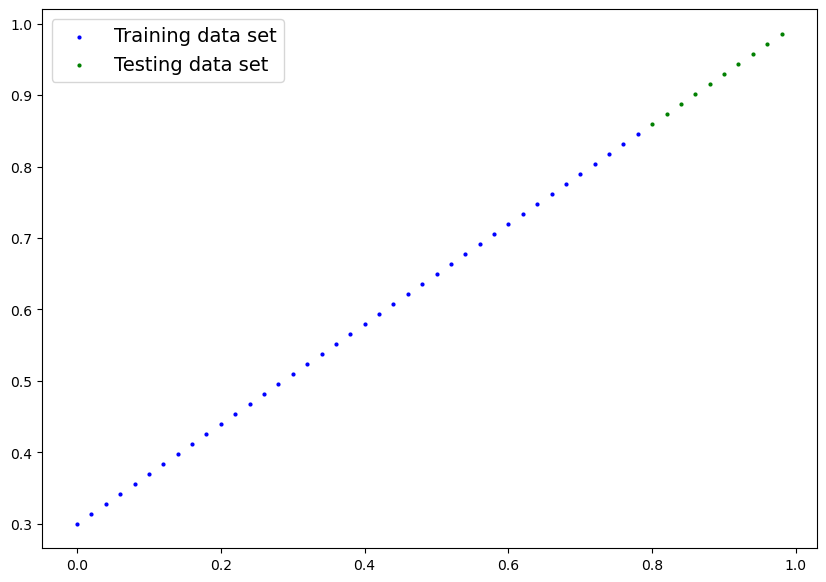

In [7]:
plot_predictions();

## 2. Building model
First pytorch model

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [8]:
# Create a Linear Regression model class
# In PyTorch, almost every model inherits from nn.Module
class LinearRegressionModel(nn.Module):
    
    # __init__ runs when we create the model object
    # This is where we define model parameters (weights, bias, layers, etc.)
    def __init__(self):
        
        # Initialize the parent class (nn.Module)
        # This is REQUIRED so PyTorch can track parameters and gradients
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))
        
        # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <-  "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula


### Pytorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a NN can be considered as a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nnModule - the base class for all NN modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizers in Pytorch live, they will help with gradient descent
* def forward() - all nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation



### Checking the contents of the pytorch model

We've created a model, see  what's inside..

Check our model parameters or what's inside of our model using `.parameters()`

In [9]:
# create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of the nn.Module)
model_0 = LinearRegressionModel()

# check out the params
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_model()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`

When we pass data through our model, it's going to run it through the `forward()` method.

### Main Difference


| Feature | Normal Forward | `torch.no_grad()` | `torch.inference_mode()` |
|----------|---------------|-------------------|--------------------------|
| Tracks gradients? | ✅ Yes | ❌ No | ❌ No |
| Builds computation graph? | ✅ Yes | ❌ No | ❌ No |
| Uses memory for autograd? | ✅ Yes | ❌ No | ❌ No (more optimized) |
| Faster? | ❌ Slightly slower | ✅ Faster | ✅ Fastest |
| Used for training? | ✅ Yes | ❌ No | ❌ No |
| Used for evaluation/testing? | ❌ Not ideal | ✅ Yes | ✅ Yes (recommended) |
| Allows tensor metadata changes? | ✅ Yes | ✅ Yes | ❌ Restricted (safer & stricter) |



In [11]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [12]:
# make predictions with model
with torch.inference_mode(): # context manager 
    y_preds = model_0(X_test)

# no grad
#with torch.no_grad():
#    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [13]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

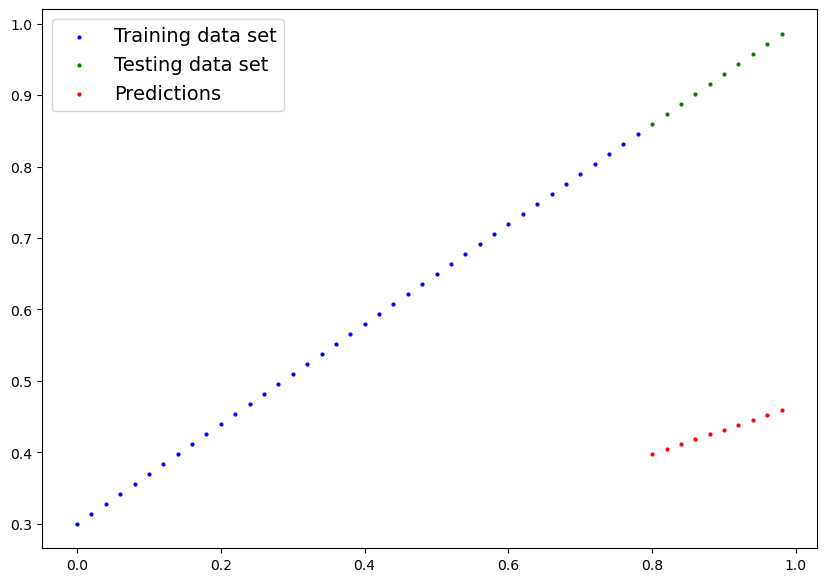

In [14]:
plot_predictions(predictions=y_preds)

## 3. Train Model
The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function

* **Note:** Loss funtion may also be called cost function or criterion in different areas.
  We will refer to it as a loss function

Things we need to train:

* **Lost function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight and bias) to improve the loss function.
  * `params` the model parameters you'd like to optimize
  * `lr` the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` result in small changes, a large `lr` results in large changes)
  
And for pytorch, we need:
* A training loop
* A testing loop

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
# Check out our model's parameters (a parameter is a value that the model sets itself during training which can be used to make predictions)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [17]:
# Setup loss func
loss_fn = nn.L1Loss() #measure how write our model's predictions are to the real labels (y_test)

# Setup optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
# optimizer says "Hey PyTorch, when I call optimizer.step() update the parameters in model_0.parameters() using the learning rate of 0.01"
# lr = learning rate = possibly the most important hyperparameter in deep learning

### Training loop (and testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data- also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [18]:

list(model_0.eval().parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# an epoch is one loop through the data passed through the model, loss function and optimizer
epochs = 1 # this is a hyperparameter because we get to choose how many times we loop through the data

# 0. Loop through the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode in PyTorch sets the model up for training (e.g. it will keep track of gradients)
    